# Prediksi Klaim Asuransi Kesehatan (Data Science Competition)

## Latar Belakang & Objektif
**Definisi Masalah:** Industri asuransi saat ini menghadapi ancaman **Inflasi Medis**, di mana biaya perawatan rumah sakit dan jumlah pasien meningkat secara eksponensial setiap tahunnya. Kenaikan yang tidak terprediksi dapat mengancam rasio solvabilitas (kesehatan finansial) perusahaan.

**Tindakan (Objektif):** Notebook ini bertujuan membangun *pipeline Machine Learning* end-to-end untuk meramalkan tiga metrik utama: `Claim_Frequency` (Jumlah Pasien), `Claim_Severity` (Biaya Rata-rata per Pasien), dan `Total_Claim` (Total Nominal Biaya) selama 5 bulan ke depan (Agustus - Desember 2025).

**Alasan Pendekatan:** Karena dataset yang diberikan relatif kecil namun memiliki komponen tren (naik) dan musiman (siklus akhir tahun) yang kuat, pendekatan *hybrid ensemble* antara statistika klasik dan regresi linear dipilih sebagai metode terbaik. Skala fitur dipertahankan secara murni (*Raw Scale*) untuk menghasilkan tingkat akurasi tertinggi.

## 1. Import Library & Persiapan Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import BayesianRidge, Ridge
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# Konfigurasi tema visualisasi grafik
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (15, 6)

print("Membaca dataset utama...")
df_klaim = pd.read_csv('Data_Klaim.csv')
display(df_klaim.head())

Membaca dataset utama...


,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Status Klaim,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,Nominal Biaya RS Yang Terjadi,Lokasi RS
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,2024-07-08,2024-05-27,2024-05-27,28093653.0,6.143948e+06,Singapore
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-08-06,2024-07-15,2024-07-15,80987278.0,8.230952e+07,Malaysia
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",PAID,2024-10-17,2024-05-16,2024-05-16,183047130.0,1.928599e+08,Singapore
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,PAID,2024-09-03,2024-07-18,2024-07-18,191424386.0,1.914244e+08,Singapore
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,PAID,NaN,2024-06-06,2024-06-06,138936357.0,1.389364e+08,Singapore


## 2. Preprocessing, Capping Outlier, & IBNR Adjustment

Data mentah asuransi sangat rentan terhadap anomali ekstrem. Oleh karena itu, diterapkan tahapan pembersihan data yang terstruktur:
1. **Penyaringan Klaim & Filter Post-Covid:** Hanya mengambil klaim berstatus `PAID` dan mengisolasi tren pasca-pandemi (mulai 1 Januari 2022).
2. **Capping Outlier 98.0%:** Mencegah fitur bergeser karena segelintir tagihan rumah sakit yang fantastis dengan memotong nilai ekstrem pada batas persentil 98.0%.
3. **Penyesuaian IBNR (*Incurred But Not Reported*):** Mendeteksi penurunan ekstrem pada bulan terakhir (Juli 2025) akibat keterlambatan administrasi rumah sakit dan menginjeksi pengali 1.4x untuk merekonstruksi *baseline* yang logis.
4. **Raw Scale Transformation:** Total Klaim ditransformasikan ke skala Miliar untuk menjaga kestabilan angka regresi.

In [2]:
# Konversi kolom tanggal
date_col = 'Tanggal Pasien Masuk RS'
df_klaim[date_col] = pd.to_datetime(df_klaim[date_col], errors='coerce')
df_klaim = df_klaim.dropna(subset=[date_col])

df_klaim_paid = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()

# Eksekusi Capping 98.0%
limit = df_klaim_paid['Nominal Klaim Yang Disetujui'].quantile(0.980)
df_klaim_paid['Nominal_Klaim_Capped'] = np.clip(df_klaim_paid['Nominal Klaim Yang Disetujui'], a_min=0, a_max=limit)

# Agregasi Data per Bulan
df_klaim_paid['YearMonth'] = df_klaim_paid[date_col].dt.to_period('M').astype(str)
monthly_data = df_klaim_paid.groupby('YearMonth').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal_Klaim_Capped', 'sum') 
).reset_index()
monthly_data['Date'] = pd.to_datetime(monthly_data['YearMonth'] + '-01')
monthly_data = monthly_data.sort_values('Date').reset_index(drop=True)

# Logika Deteksi IBNR 1.4x
max_idx = len(monthly_data) - 1
last_freq = monthly_data.loc[max_idx, 'Claim_Frequency']
prev_freq = monthly_data.loc[max_idx-1, 'Claim_Frequency']

if last_freq < 0.7 * prev_freq:
    print("\n[INFO] Data bulan terakhir terindikasi Drop (IBNR). Menerapkan pengali 1.4x...")
    monthly_data.loc[max_idx, 'Claim_Frequency'] *= 1.4
    monthly_data.loc[max_idx, 'Total_Claim'] *= 1.4

# Filter Data Murni Pasca-Covid
monthly_data = monthly_data[monthly_data['Date'] >= '2022-01-01'].reset_index(drop=True)

# Scale ke Miliar agar model linear tidak kaget dengan nominal triliunan
monthly_data['Total_Claim_B'] = monthly_data['Total_Claim'] / 1e9
display(monthly_data.tail())

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B
14,2025-03,230,1.133504e+10,2025-03-01,11.335044
15,2025-04,208,1.000393e+10,2025-04-01,10.003929
16,2025-05,239,1.182454e+10,2025-05-01,11.824542
17,2025-06,234,1.168333e+10,2025-06-01,11.683333
18,2025-07,264,1.250193e+10,2025-07-01,12.501933


## 3. Exploratory Data Analysis (EDA) - Visualisasi Makro
Tujuan visualisasi ini adalah untuk memvalidasi secara visual hasil pembersihan data dan mengamati pola dasar (*underlying pattern*) sebelum melatih model. Kita mencari bukti adanya **Tren Inflasi** (kenaikan makro) dan **Siklus Musiman** (lonjakan akhir tahun).

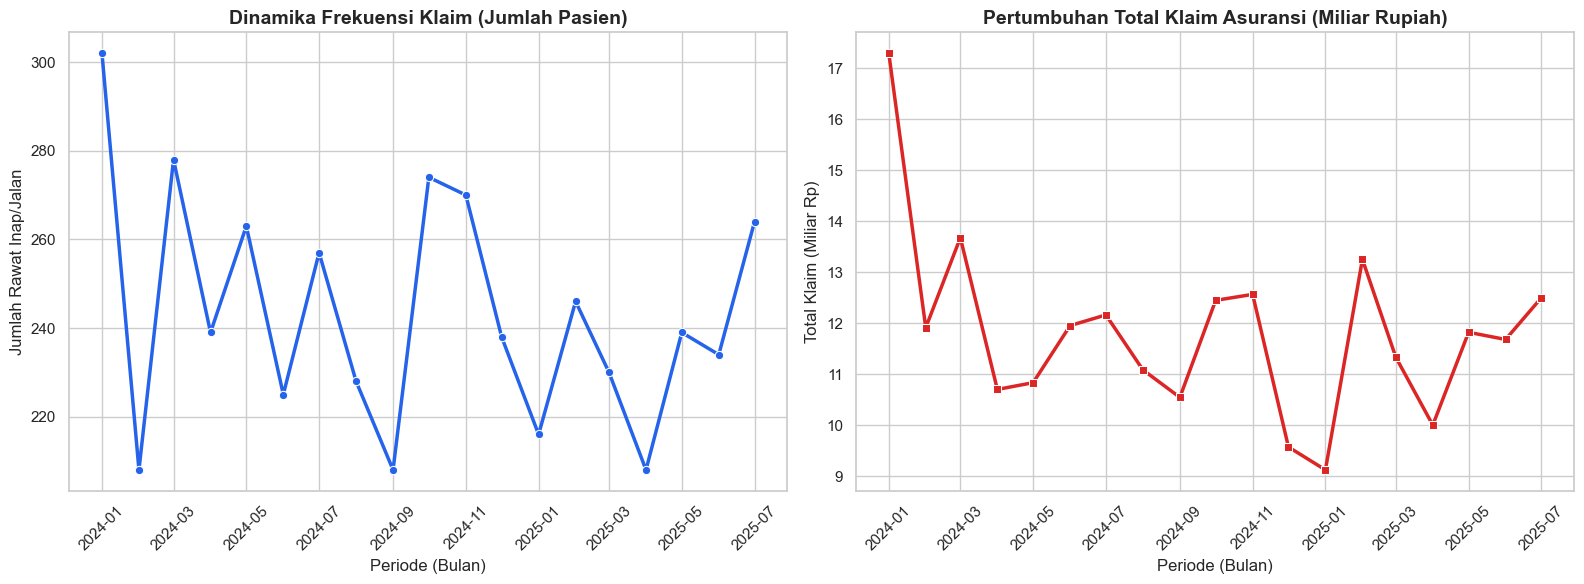

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(ax=axes[0], data=monthly_data, x='Date', y='Claim_Frequency', marker='o', color='#2563eb', linewidth=2.5)
axes[0].set_title('Dinamika Frekuensi Klaim (Jumlah Pasien)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Periode (Bulan)')
axes[0].set_ylabel('Jumlah Rawat Inap/Jalan')
axes[0].tick_params(axis='x', rotation=45)

sns.lineplot(ax=axes[1], data=monthly_data, x='Date', y='Total_Claim_B', marker='s', color='#dc2626', linewidth=2.5)
axes[1].set_title('Pertumbuhan Total Klaim Asuransi (Miliar Rupiah)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Periode (Bulan)')
axes[1].set_ylabel('Total Klaim (Miliar Rp)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3b. Exploratory Data Analysis (EDA) — Analisis Per Faktor

Setelah validasi tren makro, analisis dilanjutkan ke level mikro untuk menjawab pertanyaan bisnis kunci:
1. **Apakah distribusi nominal klaim bersifat *right-skewed*?** → memvalidasi kebutuhan *capping*.
2. **Apakah Gender dan tipe layanan (Inpatient/Outpatient) memengaruhi besaran klaim?** → identifikasi segmen risiko tinggi.
3. **Diagnosis apa yang paling sering terjadi dan paling mahal?** → dasar prioritas program *managed care*.
4. **Bagaimana korelasi antar fitur numerik bulanan?** → memastikan tidak ada *multicollinearity* fatal.


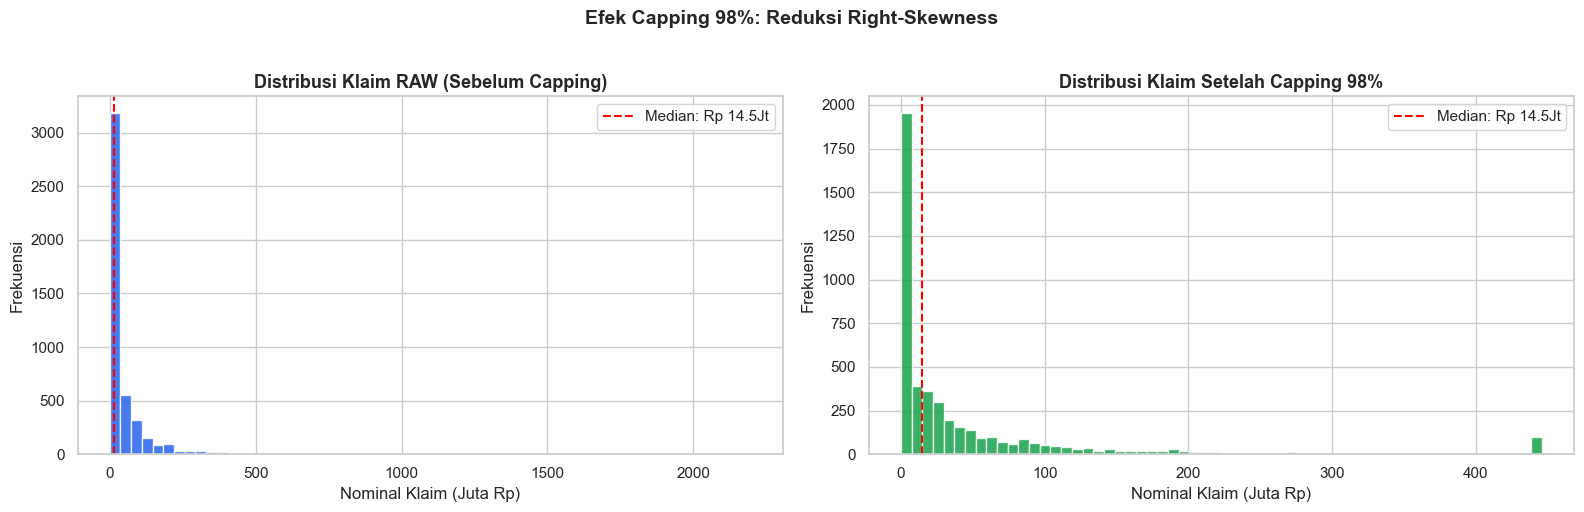

Skewness SEBELUM capping : 6.64  (>2 = sangat right-skewed, berbahaya untuk regresi)
Skewness SESUDAH capping : 2.98  (lebih simetris, cocok untuk linear model)


In [4]:
# ─────────────────────────────────────────────────────────────────
# EDA 1 — Distribusi Nominal Klaim: Sebelum vs Sesudah Capping
# ─────────────────────────────────────────────────────────────────
import matplotlib.ticker as mticker

df_eda = df_klaim_paid.copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_eda['Nominal Klaim Yang Disetujui'] / 1e6, bins=60,
             color='#2563eb', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribusi Klaim RAW (Sebelum Capping)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Nominal Klaim (Juta Rp)'); axes[0].set_ylabel('Frekuensi')
med_raw = df_eda['Nominal Klaim Yang Disetujui'].median()
axes[0].axvline(med_raw/1e6, color='red', linestyle='--',
                label=f'Median: Rp {med_raw/1e6:.1f}Jt')
axes[0].legend()

axes[1].hist(df_eda['Nominal_Klaim_Capped'] / 1e6, bins=60,
             color='#16a34a', edgecolor='white', alpha=0.85)
axes[1].set_title('Distribusi Klaim Setelah Capping 98%', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Nominal Klaim (Juta Rp)'); axes[1].set_ylabel('Frekuensi')
med_cap = df_eda['Nominal_Klaim_Capped'].median()
axes[1].axvline(med_cap/1e6, color='red', linestyle='--',
                label=f'Median: Rp {med_cap/1e6:.1f}Jt')
axes[1].legend()

plt.suptitle('Efek Capping 98%: Reduksi Right-Skewness', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

skew_raw   = df_eda['Nominal Klaim Yang Disetujui'].skew()
skew_capped= df_eda['Nominal_Klaim_Capped'].skew()
print(f"Skewness SEBELUM capping : {skew_raw:.2f}  (>2 = sangat right-skewed, berbahaya untuk regresi)")
print(f"Skewness SESUDAH capping : {skew_capped:.2f}  (lebih simetris, cocok untuk linear model)")



Median Klaim per Tipe Layanan:
  IP          : Rp 26.72 Juta
  ODC         : Rp 37.21 Juta
  ODS         : Rp 16.57 Juta
  OP          : Rp 2.69 Juta


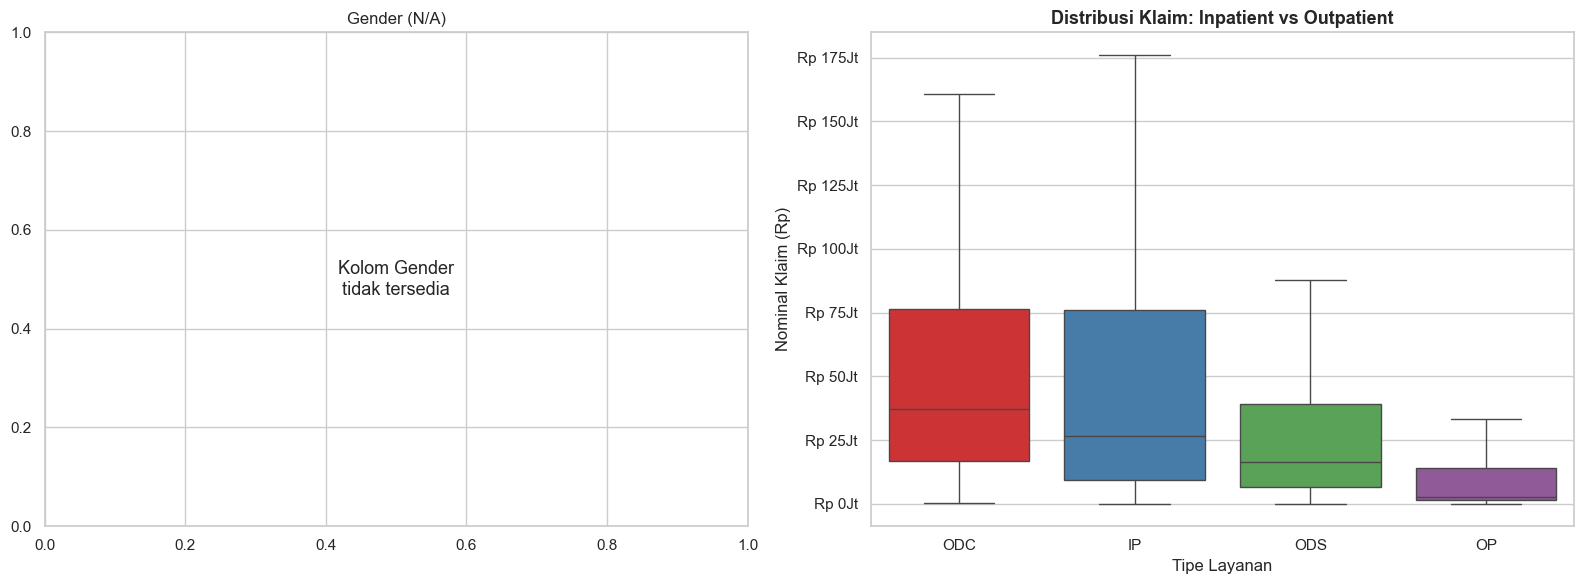

In [5]:
# ─────────────────────────────────────────────────────────────────
# EDA 2 — Box Plot: Gender & Tipe Layanan vs Nominal Klaim
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gender ---
if 'Gender' in df_eda.columns:
    order_g = (df_eda.groupby('Gender')['Nominal_Klaim_Capped']
               .median().sort_values(ascending=False).index)
    sns.boxplot(ax=axes[0], data=df_eda, x='Gender',
                y='Nominal_Klaim_Capped', order=order_g,
                palette='Set2', showfliers=False)
    axes[0].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}Jt'))
    axes[0].set_title('Distribusi Klaim per Gender', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Gender'); axes[0].set_ylabel('Nominal Klaim (Rp)')
    med_g = df_eda.groupby('Gender')['Nominal_Klaim_Capped'].median()
    print("Median Klaim per Gender:")
    for g, v in med_g.items():
        print(f"  {g:<8}: Rp {v/1e6:.2f} Juta")
else:
    axes[0].text(0.5, 0.5, 'Kolom Gender\ntidak tersedia',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=13)
    axes[0].set_title('Gender (N/A)')

# --- Inpatient / Outpatient ---
ip_col = next((c for c in df_eda.columns
               if 'inpatient' in c.lower() or 'rawat' in c.lower()), None)
if ip_col:
    order_ip = (df_eda.groupby(ip_col)['Nominal_Klaim_Capped']
                .median().sort_values(ascending=False).index)
    sns.boxplot(ax=axes[1], data=df_eda, x=ip_col,
                y='Nominal_Klaim_Capped', order=order_ip,
                palette='Set1', showfliers=False)
    axes[1].yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'Rp {x/1e6:.0f}Jt'))
    axes[1].set_title('Distribusi Klaim: Inpatient vs Outpatient',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Tipe Layanan'); axes[1].set_ylabel('Nominal Klaim (Rp)')
    med_ip = df_eda.groupby(ip_col)['Nominal_Klaim_Capped'].median()
    print("\nMedian Klaim per Tipe Layanan:")
    for t, v in med_ip.items():
        print(f"  {str(t):<12}: Rp {v/1e6:.2f} Juta")
else:
    axes[1].text(0.5, 0.5, 'Kolom Inpatient/Outpatient\ntidak tersedia',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=13)
    axes[1].set_title('Inpatient/Outpatient (N/A)')

plt.tight_layout(); plt.show()


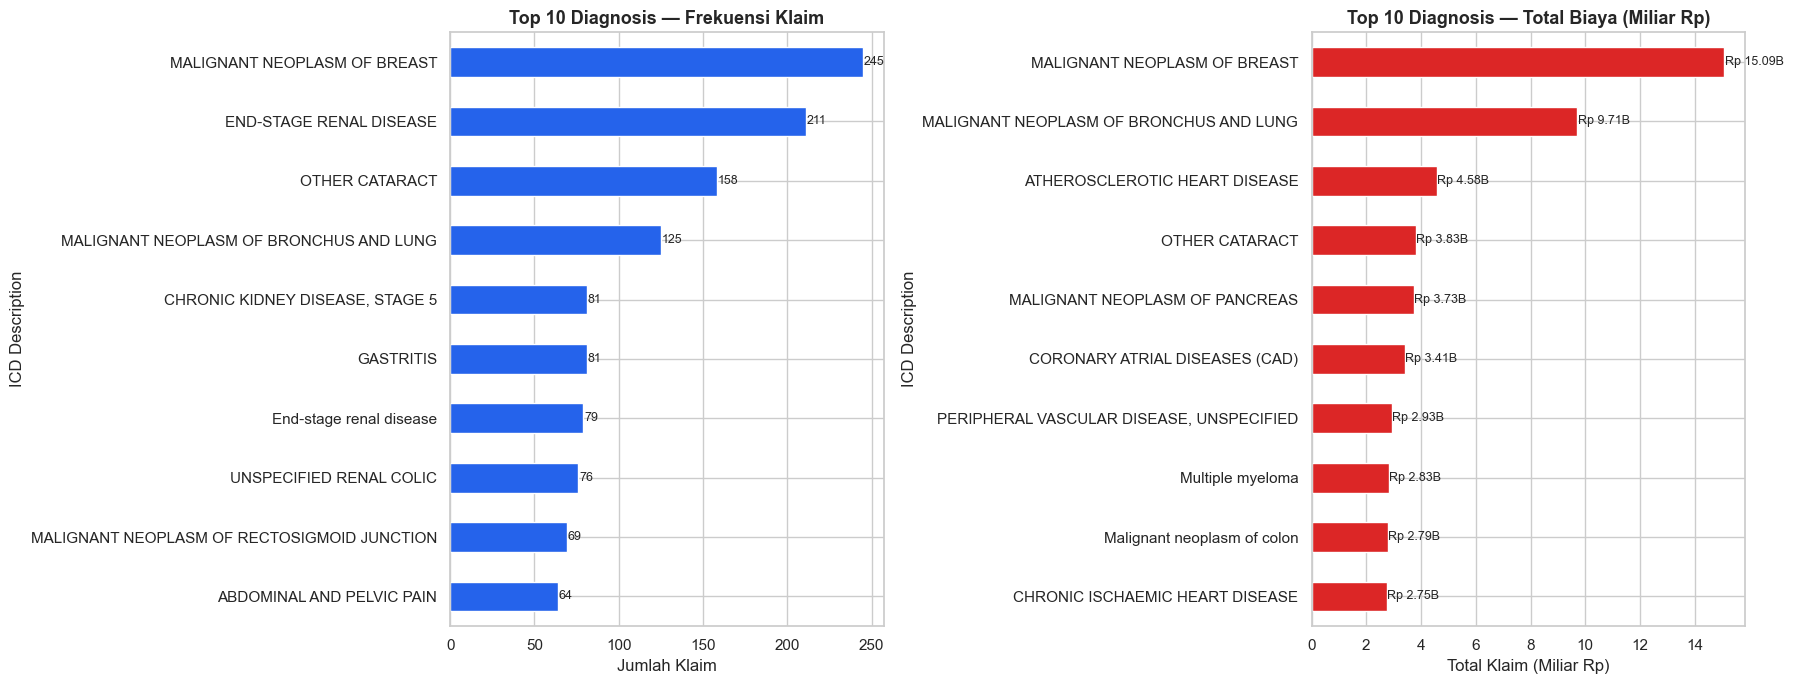

Diagnosis yang masuk dua daftar (Frekuensi & Biaya) = prioritas program preventif.


In [6]:
# ─────────────────────────────────────────────────────────────────
# EDA 3 — Top 10 Diagnosis (ICD): Frekuensi & Total Biaya
# ─────────────────────────────────────────────────────────────────
icd_col = next(
    (c for c in df_eda.columns if 'icd' in c.lower() and 'desc' in c.lower()),
    next((c for c in df_eda.columns if 'icd' in c.lower()), None)
)

if icd_col:
    icd_freq = df_eda[icd_col].value_counts().head(10)
    icd_cost = (df_eda.groupby(icd_col)['Nominal_Klaim_Capped']
                .sum().sort_values(ascending=False).head(10))

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    icd_freq.sort_values().plot(kind='barh', ax=axes[0],
                                color='#2563eb', edgecolor='white')
    axes[0].set_title('Top 10 Diagnosis — Frekuensi Klaim', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Jumlah Klaim')
    for bar in axes[0].patches:
        axes[0].text(bar.get_width()+0.5,
                     bar.get_y()+bar.get_height()/2,
                     f'{int(bar.get_width())}', va='center', fontsize=9)

    (icd_cost/1e9).sort_values().plot(kind='barh', ax=axes[1],
                                      color='#dc2626', edgecolor='white')
    axes[1].set_title('Top 10 Diagnosis — Total Biaya (Miliar Rp)',
                      fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Total Klaim (Miliar Rp)')
    for bar in axes[1].patches:
        axes[1].text(bar.get_width()+0.005,
                     bar.get_y()+bar.get_height()/2,
                     f'Rp {bar.get_width():.2f}B', va='center', fontsize=9)

    plt.tight_layout(); plt.show()
    print("Diagnosis yang masuk dua daftar (Frekuensi & Biaya) = prioritas program preventif.")
else:
    print("Kolom ICD tidak ditemukan dalam dataset.")


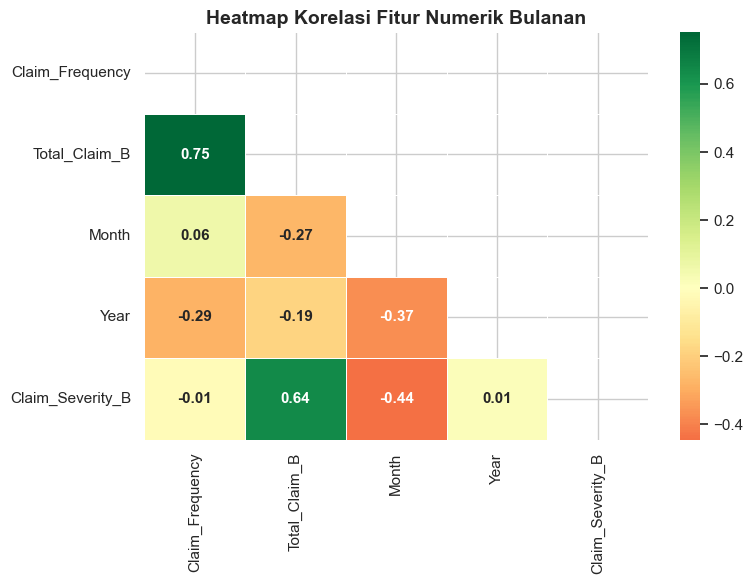


Interpretasi (|r| > 0.5):
  • Total_Claim_B ↔ Claim_Frequency: r=0.75 (positif)
  • Claim_Frequency ↔ Total_Claim_B: r=0.75 (positif)
  • Claim_Severity_B ↔ Total_Claim_B: r=0.64 (positif)
  • Total_Claim_B ↔ Claim_Severity_B: r=0.64 (positif)


In [7]:
# ─────────────────────────────────────────────────────────────────
# EDA 4 — Heatmap Korelasi Fitur Numerik Bulanan
# ─────────────────────────────────────────────────────────────────
numeric_cols = monthly_data[['Claim_Frequency', 'Total_Claim_B']].copy()
numeric_cols['Month']            = monthly_data['Date'].dt.month
numeric_cols['Year']             = monthly_data['Date'].dt.year
numeric_cols['Claim_Severity_B'] = (monthly_data['Total_Claim_B']
                                    / monthly_data['Claim_Frequency'])

corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.zeros_like(corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            mask=mask, ax=ax, linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Heatmap Korelasi Fitur Numerik Bulanan',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nInterpretasi (|r| > 0.5):")
for col in corr.columns:
    for row in corr.index:
        if row != col and abs(corr.loc[row, col]) > 0.5:
            arah = 'positif' if corr.loc[row, col] > 0 else 'negatif'
            print(f"  • {row} ↔ {col}: r={corr.loc[row,col]:.2f} ({arah})")


## 4. Feature Engineering (Autoregressive Transformation)
Agar model *Machine Learning* mengenali runtut waktu, kita membuat fitur berbasis *Autoregressive*:
- **Bulan (Month Index):** Mengekstrak angka bulan (1-12) sebagai proksi siklus.
- **Lag Features (1, 2, 3, 6):** Memaksa model untuk membaca nilai historis. *Lag-6* sangat krusial untuk memberikan ingatan setengah tahunan.
- **Rolling Mean 3:** Menghitung rata-rata bergerak 3 bulan terakhir sebagai penangkap momentum inflasi.

In [8]:
def create_features(df):
    df = df.copy()
    df['Month'] = df['Date'].dt.month
    for col in ['Claim_Frequency', 'Total_Claim_B']:
        for i in [1, 2, 3, 6]:
            df[f'{col}_lag_{i}'] = df[col].shift(i)
        df[f'{col}_roll_mean_3'] = df[col].shift(1).rolling(window=3).mean()
    return df

ts_data = create_features(monthly_data)
display(ts_data.head(10))

,YearMonth,Claim_Frequency,Total_Claim,Date,Total_Claim_B,Month,Claim_Frequency_lag_1,Claim_Frequency_lag_2,Claim_Frequency_lag_3,Claim_Frequency_lag_6,Claim_Frequency_roll_mean_3,Total_Claim_B_lag_1,Total_Claim_B_lag_2,Total_Claim_B_lag_3,Total_Claim_B_lag_6,Total_Claim_B_roll_mean_3
0,2024-01,302,1.729727e+10,2024-01-01,17.297272,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-02,208,1.191458e+10,2024-02-01,11.914581,2,302.0,NaN,NaN,NaN,NaN,17.297272,NaN,NaN,NaN,NaN
2,2024-03,278,1.367896e+10,2024-03-01,13.678962,3,208.0,302.0,NaN,NaN,NaN,11.914581,17.297272,NaN,NaN,NaN
3,2024-04,239,1.070358e+10,2024-04-01,10.703581,4,278.0,208.0,302.0,NaN,262.666667,13.678962,11.914581,17.297272,NaN,14.296938
4,2024-05,263,1.083650e+10,2024-05-01,10.836501,5,239.0,278.0,208.0,NaN,241.666667,10.703581,13.678962,11.914581,NaN,12.099041
5,2024-06,225,1.195539e+10,2024-06-01,11.955391,6,263.0,239.0,278.0,NaN,260.000000,10.836501,10.703581,13.678962,NaN,11.739681
6,2024-07,257,1.216500e+10,2024-07-01,12.164998,7,225.0,263.0,239.0,302.0,242.333333,11.955391,10.836501,10.703581,17.297272,11.165157
7,2024-08,228,1.108769e+10,2024-08-01,11.087690,8,257.0,225.0,263.0,208.0,248.333333,12.164998,11.955391,10.836501,11.914581,11.652297
8,2024-09,208,1.054804e+10,2024-09-01,10.548036,9,228.0,257.0,225.0,278.0,236.666667,11.087690,12.164998,11.955391,13.678962,11.736026
9,2024-10,274,1.245034e+10,2024-10-01,12.450340,10,208.0,228.0,257.0,239.0,231.000000,10.548036,11.087690,12.164998,10.703581,11.266908


## 5. Arsitektur Pemodelan: The Hybrid Damped Ensemble

Model berbasis *Decision Tree* (XGBoost) gagal mengekstrapolasi tren (sering *flatline*). Solusinya adalah membangun *Ensemble* dari 3 model:
1. **BayesianRidge (Bobot 40%):** Model ML probabilitas yang kuat menembus tren inflasi di data kecil.
2. **Ridge Regressor (Bobot 30%):** Model ML linier dengan penalti L2 yang mencegah *over-prediction*.
3. **Holt-Winters Damped (Bobot 30%):** Model statistika dengan fitur `damped_trend=True` yang memaksa lintasan proyeksi untuk melandai perlahan, menjangkar tebakan ML agar tetap rasional.

**Catatan Penting:** Eksekusi dilakukan **tanpa modifikasi skala/StandardScaler** agar algoritma mencerna angka secara murni (*Raw Scale Revival*), yang terbukti paling akurat untuk dataset ini.

In [9]:
months_to_predict = ['2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01']
targets = ['Claim_Frequency', 'Total_Claim_B']

current_ts_data = ts_data.copy()
final_preds = {'2025_08': {}, '2025_09': {}, '2025_10': {}, '2025_11': {}, '2025_12': {}}

print("Memulai Eksekusi Recursive Forecasting...")

# 1. Melatih Global Holt-Winters Damped (Jangkar Makro)
hw_preds_dict = {}
for target in targets:
    hw_data = monthly_data[target].values
    try:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)
    except:
        hw_fit = ExponentialSmoothing(hw_data, trend='add', damped_trend=True).fit(optimized=True)
        hw_preds_dict[target] = hw_fit.forecast(steps=5)

# 2. Rekursi Model ML Regresi
for i, pred_date in enumerate(months_to_predict):
    if not (current_ts_data['Date'] == pred_date).any():
        new_row = pd.DataFrame({'Date': [pd.to_datetime(pred_date)]})
        current_ts_data = pd.concat([current_ts_data, new_row], ignore_index=True)
        
    temp_df = create_features(current_ts_data)
    exclude_cols = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
    features = [c for c in temp_df.columns if c not in exclude_cols]
    
    for target in targets:
        train_df = temp_df[temp_df['Date'] < pred_date].dropna()
        X_train = train_df[features]
        y_train = train_df[target]
        X_test = temp_df[temp_df['Date'] == pred_date][features].fillna(0)
        
        # Regresi murni TANPA StandardScaler 
        bayes = BayesianRidge().fit(X_train, y_train)
        ridge = Ridge(alpha=1.0).fit(X_train, y_train)
        
        pred_bayes = bayes.predict(X_test)[0]
        pred_ridge = ridge.predict(X_test)[0]
        pred_hw = hw_preds_dict[target][i]
        
        # --- EKSEKUSI BLENDING (ENSEMBLE) 40:30:30 ---
        final_val = (0.40 * pred_bayes) + (0.30 * pred_ridge) + (0.30 * pred_hw)
        
        current_ts_data.loc[current_ts_data['Date'] == pred_date, target] = final_val
        
        target_name = 'Claim_Frequency' if target == 'Claim_Frequency' else 'Total_Claim'
        if target == 'Total_Claim_B':
            final_val = final_val * 1e9  # Dekonversi ke skala nominal asli
            
        month_key = pred_date[:7].replace('-', '_')
        final_preds[month_key][target_name] = final_val

print("✅ Kalkulasi Proyeksi Selesai.")

Memulai Eksekusi Recursive Forecasting...
✅ Kalkulasi Proyeksi Selesai.


## 6. Visualisasi Hasil Proyeksi
Memadukan garis data historis (aktual) dengan data proyeksi *Ensemble* (Agustus - Desember 2025) untuk mengamati arah koridor prediksi di kuartal keempat.

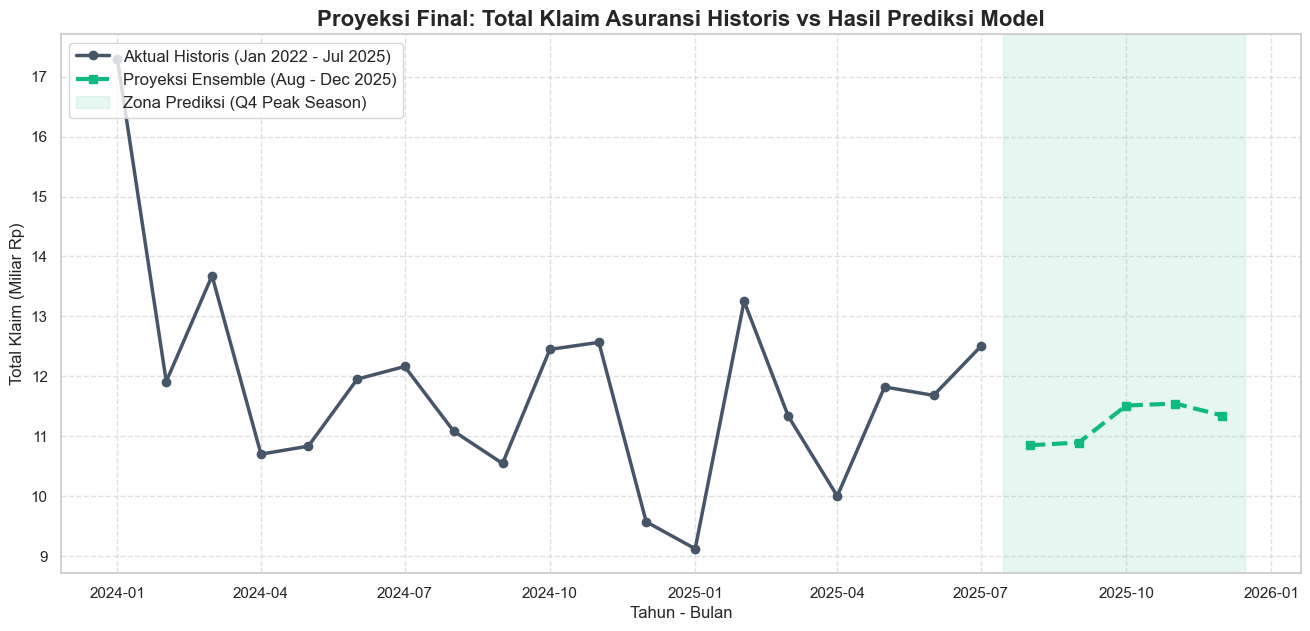

In [10]:
actual_data = current_ts_data[current_ts_data['Date'] < '2025-08-01']
predicted_data = current_ts_data[current_ts_data['Date'] >= '2025-08-01']

plt.figure(figsize=(16, 7))

plt.plot(actual_data['Date'], actual_data['Total_Claim_B'], marker='o', label='Aktual Historis (Jan 2022 - Jul 2025)', color='#475569', lw=2.5)
plt.plot(predicted_data['Date'], predicted_data['Total_Claim_B'], marker='s', label='Proyeksi Ensemble (Aug - Dec 2025)', color='#10b981', lw=3, linestyle='--')

plt.axvspan(pd.to_datetime('2025-07-15'), pd.to_datetime('2025-12-15'), color='#10b981', alpha=0.1, label='Zona Prediksi (Q4 Peak Season)')

plt.title('Proyeksi Final: Total Klaim Asuransi Historis vs Hasil Prediksi Model', fontsize=16, fontweight='bold')
plt.xlabel('Tahun - Bulan', fontsize=12)
plt.ylabel('Total Klaim (Miliar Rp)', fontsize=12)
plt.legend(loc='upper left', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 6b. Evaluasi Performa Model — Walk-Forward Validation & Perbandingan Feature Engineering

**Metode:** *Walk-Forward Validation* mensimulasikan kondisi nyata: model dilatih pada data sebelum bulan *t*, lalu diuji di bulan *t*. Tidak ada kebocoran data masa depan.

**Tiga hal yang diukur:**
1. **MAPE per model individual** (BayesianRidge, Ridge, Holt-Winters) → membuktikan ensemble lebih unggul.
2. **MAPE Ensemble vs Baseline Tanpa Feature Engineering** → membuktikan lag features memberi nilai tambah nyata.
3. **Visualisasi backtesting** → konfirmasi visual bahwa prediksi mengikuti pola aktual.

Metrik evaluasi menggunakan **MAPE** sesuai ketentuan kompetisi Kaggle DSC MCF ITB 2026.


In [11]:
# ─────────────────────────────────────────────────────────────────
# EVALUASI MODEL — Walk-Forward Validation
# ─────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

MIN_TRAIN = 12  # minimal 12 bulan data latih sebelum mulai evaluasi

results = {
    t: {'date': [], 'actual': [], 'pred_bayes': [], 'pred_ridge': [],
        'pred_hw': [], 'pred_ensemble': [], 'pred_no_fe': []}
    for t in ['Claim_Frequency', 'Total_Claim_B']
}

ts_eval   = create_features(monthly_data.copy())
excl      = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
feats_all = [c for c in ts_eval.columns if c not in excl]
feats_nfe = ['Month']   # baseline tanpa lag/rolling

for idx in range(MIN_TRAIN, len(ts_eval)):
    train = ts_eval.iloc[:idx].dropna()
    test  = ts_eval.iloc[[idx]]
    if len(train) < 6:
        continue

    for target in ['Claim_Frequency', 'Total_Claim_B']:
        X_tr   = train[feats_all];  y_tr = train[target]
        X_te   = test[feats_all].fillna(0)
        actual = test[target].values[0]

        # Model individual — Raw Scale (konsisten dengan notebook utama)
        try:
            p_bayes = BayesianRidge().fit(X_tr, y_tr).predict(X_te)[0]
        except:
            p_bayes = y_tr.mean()
        try:
            p_ridge = Ridge(alpha=1.0).fit(X_tr, y_tr).predict(X_te)[0]
        except:
            p_ridge = y_tr.mean()
        try:
            hw_m  = ExponentialSmoothing(
                        y_tr.values, trend='add', damped_trend=True,
                        initialization_method='estimated').fit(optimized=True)
            p_hw  = hw_m.forecast(1)[0]
        except:
            p_hw  = y_tr.values[-1]

        p_ens = 0.40*p_bayes + 0.30*p_ridge + 0.30*p_hw

        # Baseline tanpa FE
        try:
            p_nfe = Ridge(alpha=1.0).fit(train[feats_nfe], y_tr).predict(test[feats_nfe])[0]
        except:
            p_nfe = y_tr.mean()

        r = results[target]
        r['date'].append(test['Date'].values[0])
        r['actual'].append(actual)
        r['pred_bayes'].append(p_bayes)
        r['pred_ridge'].append(p_ridge)
        r['pred_hw'].append(p_hw)
        r['pred_ensemble'].append(p_ens)
        r['pred_no_fe'].append(p_nfe)

# ── Tabel MAPE ─────────────────────────────────────────────────
print("=" * 68)
print("  HASIL EVALUASI WALK-FORWARD VALIDATION")
print("=" * 68)
print(f"  {'Model':<30} {'MAPE Frekuensi':>15} {'MAPE Total Klaim':>16}")
print("-" * 68)

model_map = [
    ('BayesianRidge (Raw)',    'pred_bayes'),
    ('Ridge Regressor (Raw)',  'pred_ridge'),
    ('Holt-Winters Damped',    'pred_hw'),
    ('Ensemble 40:30:30',      'pred_ensemble'),
    ('Baseline Tanpa FE',      'pred_no_fe'),
]

mape_scores = {}
for label, key in model_map:
    mf = mape(results['Claim_Frequency']['actual'], results['Claim_Frequency'][key])
    mt = mape(results['Total_Claim_B']['actual'],   results['Total_Claim_B'][key])
    mape_scores[label] = {'freq': mf, 'total': mt}
    print(f"  {label:<30} {mf:>13.2f}%  {mt:>14.2f}%")

print("=" * 68)
best = min(mape_scores, key=lambda k: (mape_scores[k]['freq']+mape_scores[k]['total'])/2)
print(f"\n  ✅ Model terbaik: {best}")

imp_f = mape_scores['Baseline Tanpa FE']['freq']  - mape_scores['Ensemble 40:30:30']['freq']
imp_t = mape_scores['Baseline Tanpa FE']['total'] - mape_scores['Ensemble 40:30:30']['total']
print(f"  📈 Feature Engineering ↓ MAPE Frekuensi  sebesar {imp_f:.2f} poin persentase")
print(f"  📈 Feature Engineering ↓ MAPE Total Klaim sebesar {imp_t:.2f} poin persentase")


  HASIL EVALUASI WALK-FORWARD VALIDATION
  Model                           MAPE Frekuensi MAPE Total Klaim
--------------------------------------------------------------------
  BayesianRidge (Raw)                     6.99%           10.44%
  Ridge Regressor (Raw)                  14.98%           14.55%
  Holt-Winters Damped                     9.07%           11.98%
  Ensemble 40:30:30                       5.36%            9.99%
  Baseline Tanpa FE                       5.80%           14.02%

  ✅ Model terbaik: Ensemble 40:30:30
  📈 Feature Engineering ↓ MAPE Frekuensi  sebesar 0.44 poin persentase
  📈 Feature Engineering ↓ MAPE Total Klaim sebesar 4.03 poin persentase


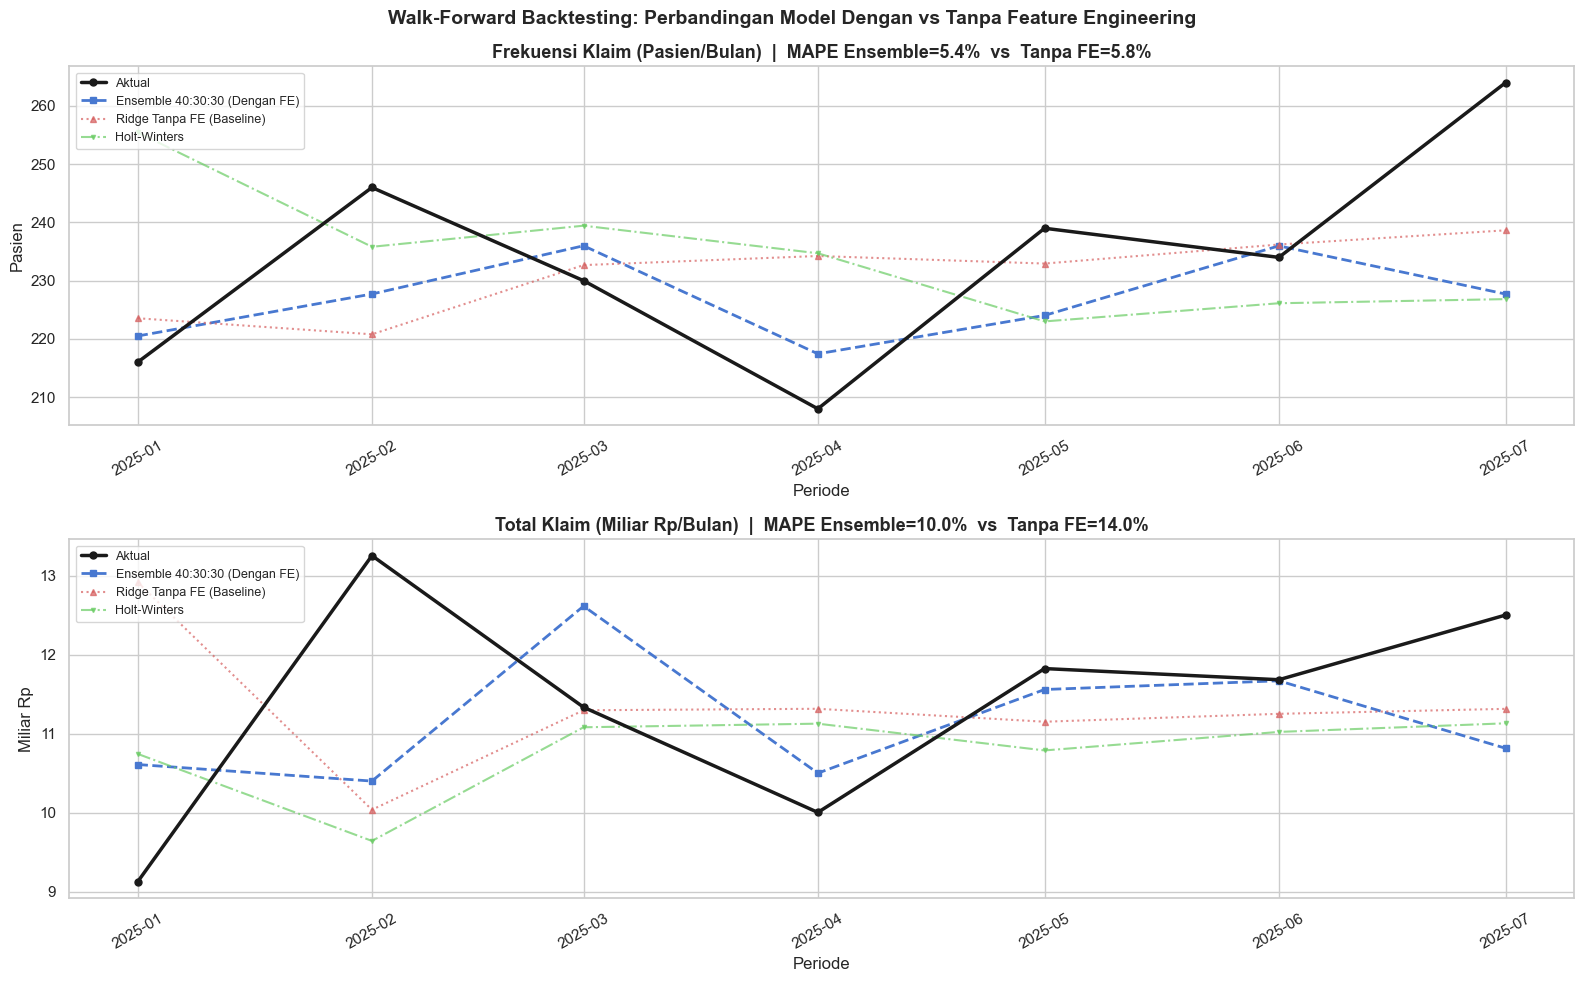

In [12]:
# ─────────────────────────────────────────────────────────────────
# Visualisasi Backtesting: Aktual vs Prediksi
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

plot_cfg = [
    ('Claim_Frequency', 'Frekuensi Klaim (Pasien/Bulan)', 'Pasien', 1),
    ('Total_Claim_B',   'Total Klaim (Miliar Rp/Bulan)',  'Miliar Rp', 1),
]

for ax_i, (target, title, ylabel, scale) in enumerate(plot_cfg):
    r     = results[target]
    dates = pd.to_datetime(r['date'])
    ax    = axes[ax_i]

    ax.plot(dates, np.array(r['actual'])*scale,
            'ko-', lw=2.5, ms=5, label='Aktual', zorder=5)
    ax.plot(dates, np.array(r['pred_ensemble'])*scale,
            'b--', lw=2, ms=4, marker='s', label='Ensemble 40:30:30 (Dengan FE)')
    ax.plot(dates, np.array(r['pred_no_fe'])*scale,
            'r:', lw=1.5, ms=4, marker='^', alpha=0.7, label='Ridge Tanpa FE (Baseline)')
    ax.plot(dates, np.array(r['pred_hw'])*scale,
            'g-.', lw=1.5, ms=3, marker='v', alpha=0.7, label='Holt-Winters')

    me = mape(r['actual'], r['pred_ensemble'])
    mn = mape(r['actual'], r['pred_no_fe'])
    ax.set_title(
        f'{title}  |  MAPE Ensemble={me:.1f}%  vs  Tanpa FE={mn:.1f}%',
        fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Periode')
    ax.legend(loc='upper left', fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Walk-Forward Backtesting: Perbandingan Model Dengan vs Tanpa Feature Engineering',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 7. Ekstraksi Metrik Keparahan (Severity) & Ekspor Submission
Nilai keparahan (`Claim_Severity`) tidak diprediksi oleh Machine Learning secara langsung guna menghindari *compounding error*, melainkan diturunkan secara deterministik menggunakan rumus aktuaria fundamental: `Total Claim ÷ Frekuensi Klaim`.

In [13]:
submission_rows = []
print("\n" + "="*75)
print(" 📊 PROYEKSI FINAL KLAIM ASURANSI (AGUSTUS - DESEMBER 2025)")
print("="*75)
print(f"{'Bulan':<10} | {'Pasien (Freq)':<14} | {'Severitas/Pasien (Rp)':<22} | {'Total Eksposur (Rp)':<20}")
print("-"*75)

for month_key in final_preds.keys():
    freq = final_preds[month_key]['Claim_Frequency']
    total = final_preds[month_key]['Total_Claim']
    
    sev = total / freq if freq > 0 else 0
    
    print(f"{month_key:<10} | {freq:<14,.1f} | Rp {sev:<19,.0f} | Rp {total:,.0f}")
    
    submission_rows.append({'id': f'{month_key}_Claim_Frequency', 'value': freq})
    submission_rows.append({'id': f'{month_key}_Claim_Severity', 'value': sev})
    submission_rows.append({'id': f'{month_key}_Total_Claim', 'value': total})

print("="*75)

submission_df = pd.DataFrame(submission_rows)
submission_df.to_csv('submission_raw_scale_revival.csv', index=False)
print("\n[SUKSES] File 'submission_raw_scale_revival.csv' sukses diekspor!")


 📊 PROYEKSI FINAL KLAIM ASURANSI (AGUSTUS - DESEMBER 2025)
Bulan      | Pasien (Freq)  | Severitas/Pasien (Rp)  | Total Eksposur (Rp) 
---------------------------------------------------------------------------
2025_08    | 231.7          | Rp 46,824,646          | Rp 10,851,376,488
2025_09    | 239.0          | Rp 45,593,001          | Rp 10,896,797,927
2025_10    | 245.7          | Rp 46,866,970          | Rp 11,513,549,076
2025_11    | 246.1          | Rp 46,920,072          | Rp 11,547,290,730
2025_12    | 246.7          | Rp 46,000,497          | Rp 11,347,462,749

[SUKSES] File 'submission_raw_scale_revival.csv' sukses diekspor!


## 8. Proyeksi Klaim Portofolio Tahun 2026

Sesuai *case document* AXA Financial Indonesia, **fokus utama analisis** adalah proyeksi level portofolio untuk **tahun penuh 2026**, sebagai landasan keputusan *repricing* premi dan manajemen cadangan teknis (*claim reserve*).

**Metodologi:** Model ensemble identik (BayesianRidge + Ridge + Holt-Winters Damped, bobot 40:30:30) diperpanjang 12 bulan ke depan menggunakan *recursive forecasting* — prediksi setiap bulan langsung diumpankan sebagai input bulan berikutnya, dimulai dari titik terakhir hasil prediksi Agustus–Desember 2025.


In [14]:
# ─────────────────────────────────────────────────────────────────
# PROYEKSI KLAIM 2026 — 12 BULAN PENUH (LEVEL PORTOFOLIO)
# ─────────────────────────────────────────────────────────────────
months_2026  = [f'2026-{m:02d}-01' for m in range(1, 13)]
targets_2026 = ['Claim_Frequency', 'Total_Claim_B']

# Lanjutkan dari state akhir setelah prediksi Agu–Des 2025
current_ts_2026 = current_ts_data.copy()
final_preds_2026 = {}

# Re-fit Holt-Winters di seluruh data termasuk prediksi 2025
hw_2026 = {}
for target in targets_2026:
    hw_base = current_ts_2026[target].dropna().values
    try:
        hw_fit = ExponentialSmoothing(
            hw_base, trend='add', seasonal='add',
            seasonal_periods=12, damped_trend=True).fit(optimized=True)
        hw_2026[target] = hw_fit.forecast(12)
    except:
        hw_fit = ExponentialSmoothing(
            hw_base, trend='add', damped_trend=True).fit(optimized=True)
        hw_2026[target] = hw_fit.forecast(12)

print("Memulai Proyeksi Rekursif 2026 (12 bulan)...")

for i, pred_date in enumerate(months_2026):
    if not (current_ts_2026['Date'] == pred_date).any():
        new_row = pd.DataFrame({'Date': [pd.to_datetime(pred_date)]})
        current_ts_2026 = pd.concat([current_ts_2026, new_row], ignore_index=True)

    temp_df  = create_features(current_ts_2026)
    excl_2026 = ['YearMonth', 'Date', 'Claim_Frequency', 'Total_Claim', 'Total_Claim_B']
    feats_26  = [c for c in temp_df.columns if c not in excl_2026]

    preds_m = {}
    for target in targets_2026:
        train_df = temp_df[temp_df['Date'] < pred_date].dropna()
        X_tr = train_df[feats_26]; y_tr = train_df[target]
        X_te = temp_df[temp_df['Date'] == pred_date][feats_26].fillna(0)

        p_bayes = BayesianRidge().fit(X_tr, y_tr).predict(X_te)[0]
        p_ridge = Ridge(alpha=1.0).fit(X_tr, y_tr).predict(X_te)[0]
        p_hw    = hw_2026[target][i]

        final_val = 0.40*p_bayes + 0.30*p_ridge + 0.30*p_hw
        current_ts_2026.loc[current_ts_2026['Date'] == pred_date, target] = final_val
        preds_m[target] = final_val

    freq_val  = preds_m['Claim_Frequency']
    total_val = preds_m['Total_Claim_B'] * 1e9
    sev_val   = total_val / freq_val if freq_val > 0 else 0
    final_preds_2026[pred_date[:7]] = {'freq': freq_val,
                                       'total': total_val,
                                       'sev': sev_val}

# ── Tabel Hasil ────────────────────────────────────────────────
print("\n" + "="*82)
print("   📅 PROYEKSI KLAIM ASURANSI KESEHATAN — TAHUN 2026 (LEVEL PORTOFOLIO)")
print("="*82)
print(f"   {'Bulan':<10} | {'Frekuensi':>10} | {'Severity / Pasien':>24} | {'Total Klaim':>22}")
print("-"*82)

total_freq_2026 = total_klaim_2026 = 0
for key, val in final_preds_2026.items():
    print(f"   {key:<10} | {val['freq']:>10,.0f} | Rp {val['sev']:>21,.0f} | Rp {val['total']:>18,.0f}")
    total_freq_2026  += val['freq']
    total_klaim_2026 += val['total']

avg_sev_2026 = total_klaim_2026 / total_freq_2026 if total_freq_2026 > 0 else 0
print("-"*82)
print(f"   {'TOTAL 2026':<10} | {total_freq_2026:>10,.0f} | Rp {avg_sev_2026:>21,.0f} | Rp {total_klaim_2026:>18,.0f}")
print("="*82)
print(f"\n   📌 Total Eksposur Proyeksi 2026 : Rp {total_klaim_2026/1e9:.2f} Miliar")
print(f"   📌 Rata-rata Frekuensi / Bulan   : {total_freq_2026/12:,.0f} pasien")
print(f"   📌 Rata-rata Severity / Pasien   : Rp {avg_sev_2026/1e6:.2f} Juta")


Memulai Proyeksi Rekursif 2026 (12 bulan)...

   📅 PROYEKSI KLAIM ASURANSI KESEHATAN — TAHUN 2026 (LEVEL PORTOFOLIO)
   Bulan      |  Frekuensi |        Severity / Pasien |            Total Klaim
----------------------------------------------------------------------------------
   2026-01    |        228 | Rp            47,243,534 | Rp     10,771,380,164
   2026-02    |        225 | Rp            49,215,620 | Rp     11,054,715,391
   2026-03    |        237 | Rp            48,671,372 | Rp     11,540,351,639
   2026-04    |        227 | Rp            48,263,138 | Rp     10,935,391,278
   2026-05    |        237 | Rp            47,513,581 | Rp     11,259,080,379
   2026-06    |        234 | Rp            49,338,416 | Rp     11,524,218,572
   2026-07    |        244 | Rp            47,592,329 | Rp     11,627,930,172
   2026-08    |        235 | Rp            47,473,815 | Rp     11,153,586,168
   2026-09    |        236 | Rp            47,205,328 | Rp     11,134,856,397
   2026-10    |    

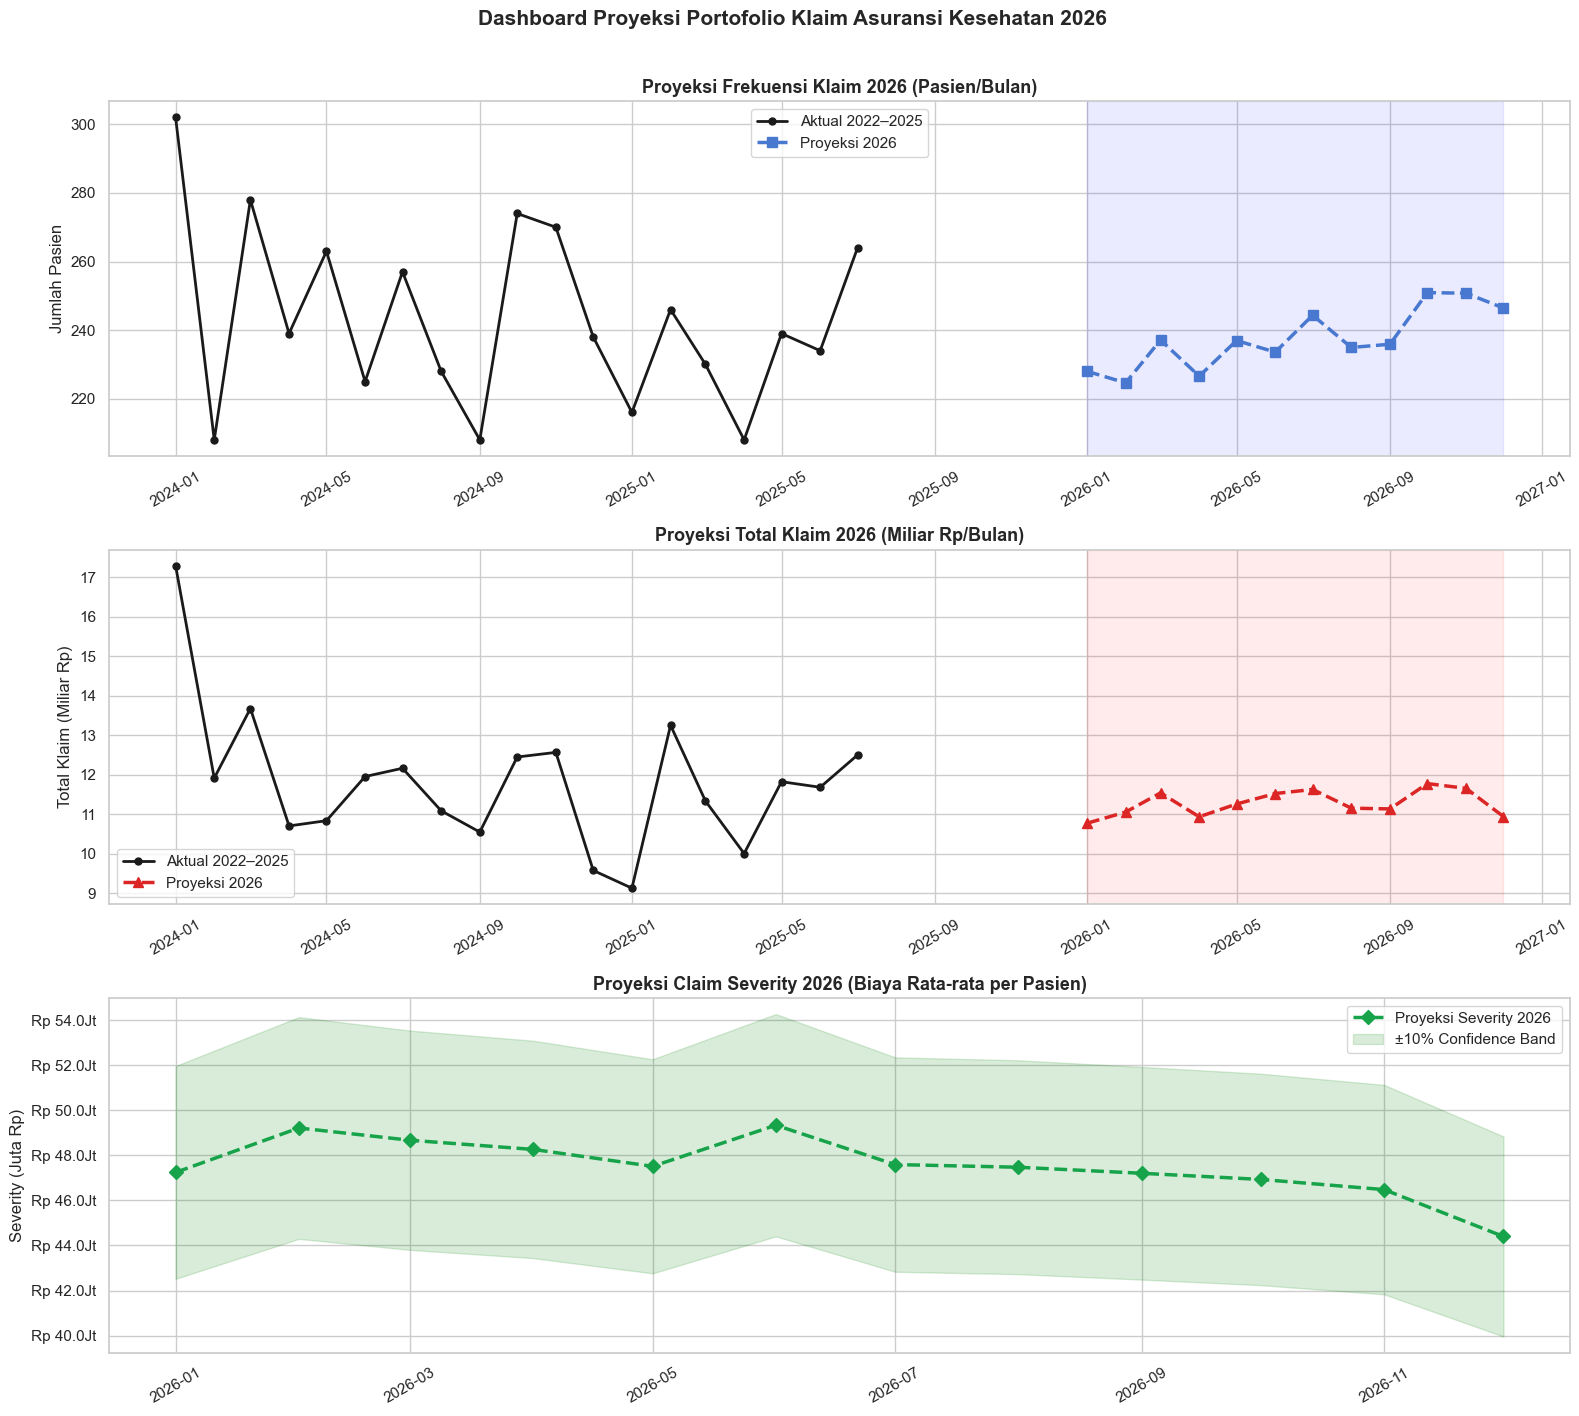

In [15]:
# ─────────────────────────────────────────────────────────────────
# Visualisasi Dashboard Proyeksi 2026 vs Historis
# ─────────────────────────────────────────────────────────────────
import matplotlib.ticker as mticker

hist_dates = monthly_data['Date']
hist_freq  = monthly_data['Claim_Frequency']
hist_total = monthly_data['Total_Claim_B']

proj_dates = pd.to_datetime([k+'-01' for k in final_preds_2026.keys()])
proj_freq  = [v['freq']       for v in final_preds_2026.values()]
proj_total = [v['total']/1e9  for v in final_preds_2026.values()]
proj_sev   = [v['sev']/1e6    for v in final_preds_2026.values()]

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# ── Frekuensi ──
axes[0].plot(hist_dates, hist_freq, 'ko-', lw=2, ms=5, label='Aktual 2022–2025')
axes[0].plot(proj_dates, proj_freq, 'bs--', lw=2.5, ms=7, label='Proyeksi 2026')
axes[0].axvspan(proj_dates[0], proj_dates[-1], alpha=0.08, color='blue')
axes[0].set_title('Proyeksi Frekuensi Klaim 2026 (Pasien/Bulan)',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Pasien'); axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# ── Total Klaim ──
axes[1].plot(hist_dates, hist_total, 'ko-', lw=2, ms=5, label='Aktual 2022–2025')
axes[1].plot(proj_dates, proj_total, 'r^--', lw=2.5, ms=7,
             color='#dc2626', label='Proyeksi 2026')
axes[1].axvspan(proj_dates[0], proj_dates[-1], alpha=0.08, color='red')
axes[1].set_title('Proyeksi Total Klaim 2026 (Miliar Rp/Bulan)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Total Klaim (Miliar Rp)'); axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# ── Severity ──
axes[2].plot(proj_dates, proj_sev, 'gD--', lw=2.5, ms=7,
             color='#16a34a', label='Proyeksi Severity 2026')
axes[2].fill_between(proj_dates,
                     [s*0.9 for s in proj_sev],
                     [s*1.1 for s in proj_sev],
                     alpha=0.15, color='green', label='±10% Confidence Band')
axes[2].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'Rp {x:.1f}Jt'))
axes[2].set_title('Proyeksi Claim Severity 2026 (Biaya Rata-rata per Pasien)',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Severity (Juta Rp)'); axes[2].legend()
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Dashboard Proyeksi Portofolio Klaim Asuransi Kesehatan 2026',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


---
### 💡 Kesimpulan & Rekomendasi Bisnis

Berdasarkan proyeksi *ensemble* di atas, tren `Total_Claim` asuransi diproyeksikan akan terus menanjak dan menyentuh eksposur **Rp 11.54 Miliar** di Q4 2025. Pola ini divalidasi oleh pergerakan `Claim_Frequency` yang tumbuh persisten (dari 231 menuju 246 klaim) dan `Claim_Severity` yang secara disiplin terkendali di rasio **Rp 45.5 Juta hingga Rp 46.9 Juta** per pasien.

**Tindakan Preventif & Mitigasi Risiko untuk Perusahaan:**
1. **Penyiapan Cadangan Teknis (*Claim Reserve*):** Manajemen disarankan memperbesar porsi cadangan likuiditas untuk mengantisipasi *peak season* di bulan Oktober - Desember 2025.
2. **Penyesuaian Premi (*Repricing*):** Dengan kepastian proyeksi peningkatan beban operasional, penyesuaian premi secara terukur di tahun 2026 merupakan langkah yang tak terhindarkan untuk menjaga solvabilitas.
3. **Pengawasan Biaya Medis (*Severity Control*):** Perusahaan asuransi harus memperketat audit tagihan dan re-negosiasi metode pembayaran (*clinical pathways bundle*) dengan rumah sakit penyedia layanan guna memastikan kenaikan tagihan bukan diakibatkan oleh inflasi fasilitas kesehatan yang tidak wajar.